### Nowcasting Bahamas's GDP

Last Edit: 2025-12-07 (Time use optimization)

This code:

- Uses LARS to define best nowcasting covariates
- Loops across all plausible sets of covariates
- Fits nowcasting models, predicts in test data, and produces out of sample estimates
- Results are stored in tables

Models

- OLS
- OLS Ridge
- LASSO
- Elastic Net
- Decision Tree
- Random Forest
- Gradient Boosting Tree
- Long Short Term Memory


In [1]:
import os
import pandas as pd
import numpy as np
from sklearn import linear_model
import matplotlib.pyplot as plt
from tqdm import tqdm
import time

import pmdarima as pm
import warnings

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import Lasso
from sklearn import tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from copy import deepcopy
from sklearn.linear_model import Lars

import torch
from nowcast_lstm.LSTM import LSTM
warnings.filterwarnings("ignore", category=UserWarning)

d = os.getcwd()+"/"
PATH_RAW = f"{d}/../data"
PATH_DATA = f"{d}/../data"
PATH_OUTPUT = f"{d}/../output"

#########################################################
# DEFINE TRAIN/TEST SET
target_variable = 'RGDP0000'
lags = list(range(-2, 3))
# train and test dates
train_start_date = "2015-06-01"
test_start_date = "2022-06-01"
test_end_date = "2023-12-01"
#########################################################

#########################################################
# DEFINE OUT OF SAMPLE PREDICTION (LAST DATE)
desired_date = pd.to_datetime("2025-03-01")
#########################################################

from datetime import datetime
today = datetime.today()
date_str = today.strftime("%Y%m%d")
#########################################################
# DEFINE FILES:
forecast_file = f"fcst_{date_str}.xlsx"
performance_file = f"perf_{date_str}.xlsx"
outofsample_file = f"oos_{date_str}.xlsx"

# Last performance file. Name or None
last_performance = None

#########################################################
# Define models
run = {
    'ols' : 1 ,
    'olsr' : 0 ,
    'enet' : 0 ,
    'lasso' : 0 ,
    'gbt' : 0 ,
    'dt' : 0 ,
    'rf' : 0 ,
    'lstm' : 0 ,
}

# Number of RF/DT/GBT iterations:
_iter_ = 10
#########################################################
data = pd.read_csv(f"{PATH_DATA}/data.csv", parse_dates=["date"], index_col='date')
metadata = pd.read_csv(f"{PATH_DATA}/meta_full.csv")


meta_col = 'ticket'
cpi = 'MCPI0000'
# this loops deflates nominal variables using the cpi
base = data[cpi][data.index.year == 2018].mean()
nominal = metadata.loc[metadata['nominal']==1][meta_col].values
for column in data.columns :
    if column in nominal : data[column] = data[column]*data[cpi]/base

from statsmodels.tsa.seasonal import seasonal_decompose


# this loop seasonally-adjusts the variables
quarterly = metadata.loc[metadata['freq']=='q'][meta_col].values
monthly = metadata.loc[metadata['freq']=='m'][meta_col].values
weekly = metadata.loc[metadata['freq']=='w'][meta_col].values
daily = metadata.loc[metadata['freq']=='d'][meta_col].values
for column in data.columns :
    if len(data[column].dropna(how='all', axis=0))>12 :
        if column in quarterly :
            data[column] = seasonal_decompose(data[column].dropna(how='all', axis=0), model='additive', extrapolate_trend='freq', period=4).trend
        elif column in monthly :
            data[column] = seasonal_decompose(data[column].dropna(how='all', axis=0), model='additive', extrapolate_trend='freq', period=12).trend
        elif column in daily :
            data[column] = seasonal_decompose(data[column].dropna(how='all', axis=0), model='additive', extrapolate_trend='freq', period=31).trend

# this loop calculates growth rates
for column in data.columns :
    if column in quarterly : data[column] = data[column].dropna(how='all', axis=0).pct_change()*100
    else : data[column] = data[column].dropna(how='all', axis=0).pct_change()*100


data.drop(cpi, axis=1, inplace=True)
data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(how='all', axis=1, inplace=True)

data = data[~(data.index < '2015-01-01')].reset_index(drop=False)
data = data.set_index('date').dropna(how='all', axis=0)


print("================== Library Versions =================")
import sklearn
print("scikit-learn:", sklearn.__version__)
print("numpy:", np.__version__)
print("pandas:", pd.__version__)

================== Library Versions =================
scikit-learn: 1.7.0
numpy: 2.2.5
pandas: 2.3.0


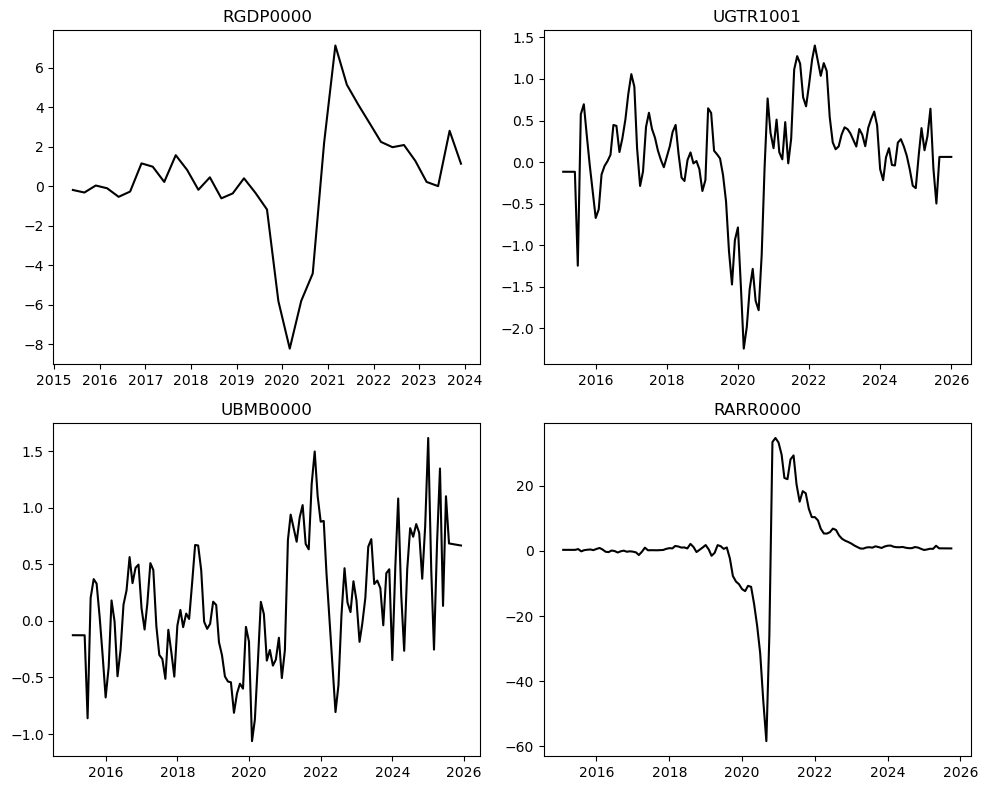

In [2]:
df1 = data[['RGDP0000', 'UGTR1001', "UBMB0000", 'RARR0000']]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, col in zip(axes.flatten(), df1.columns):
    ax.plot(df1[col].dropna().sort_index(),  color="black")
    ax.set_title(col)

plt.tight_layout()
plt.show()

## Functions

In [3]:
# ALL HELPER FUNCTIONS AND MODELS ARE DEFINED HERE
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

scaler = StandardScaler()
from sklearn.decomposition import PCA

#optimal_r = estimate_factors(X, r_max=10, criterion='IC1')
def estimate_factors(X, r_max=10, criterion='IC1'):
    '''
    Information criteria to PCA.
    Bai and Ng (2002)
    inputs:
    - X: df
    - r_max: max number of factors (should be less than T or N)
    - criterion: conservative criteria is IC3
    '''
    
    T, N = X.shape
    r_max = min(r_max, T - 1)  # enforce theoretical max
    IC_vals = []
    
    for r in range(r_max + 1):
        if r == 0:
            sigma2_r = np.mean(X.values ** 2)
        else:
            pca = PCA(n_components=r)
            X_scaled = scaler.fit_transform(X)
            F_hat = pca.fit_transform(X_scaled)
            Lambda_hat = X_scaled.T @ F_hat / T
            X_hat = F_hat @ Lambda_hat.T
            sigma2_r = np.mean((X_scaled - X_hat).values ** 2)
    
        if criterion == 'IC1':
            penalty = r * (N + T) / (N * T) * np.log(N * T / (N + T))
        elif criterion == 'IC2':
            penalty = r * (N + T) / (N * T) * np.log(min(N, T))
        elif criterion == 'IC3':
            penalty = r * np.log(min(N, T)) / min(N, T)
        else:
            raise ValueError("Invalid criterion")
    
        IC_vals.append(np.log(sigma2_r) + penalty)

    return np.argmin(IC_vals)


def lars_variable_ranking(df, target, max_vars=None, test = None , factors = 5 ):
    """
    Stepwise LARS variable selection: rank variables by their entry into the model.
    - df: DataFrame with predictors and target
    - target: name of the target variable
    - max_vars: number of variables to select; if None, continue until all are ranked
    Returns:
    - selected_vars: ordered list of variable names by entry into the LARS model

    Chinn, M. D., Meunier, B., & Stumpner, S. (2023). Nowcasting world trade with machine learning: a three-step approach (No. w31419). National Bureau of Economic Research.
    """
    data = deepcopy(df)
    
    selected_order = []
    count = 0
    max_vars = max_vars or (df.shape[1] - 1)

    while count < max_vars:
        X = data.drop(columns=[target])
        y = data[target]

        # Stop if no variables remain
        if X.shape[1] == 0 : break

        # Fit LARS model
        model = Lars(n_nonzero_coefs=X.shape[1], jitter=0 , random_state=0)
        model.fit(X, y)

        # coef_path_ has shape (n_features, n_steps)
        coef_path = np.array(model.coef_path_)
        # Count how many times each variable is zero
        zero_counts = (coef_path == 0).sum(axis=1)

        # Summary table
        out = pd.DataFrame({'Variable': X.columns, 'ZeroCount': zero_counts})
        out = out.sort_values('ZeroCount')
        
        # Take variables that are uniquely at this ZeroCount level
        grouped = out.groupby('ZeroCount')
        selected = grouped.filter(lambda g: len(g) == 1)

        # If nothing uniquely enters, dump all remaining vars
        if selected.empty:
            remaining = X.columns.tolist() # Take all remaining variables
            selected = pd.DataFrame({'Variable': remaining, 'ZeroCount': [count]*len(remaining)})
            selected_order.extend(remaining) # Add them to the selected_order list
            print("Warning: Using fallback procedure for LARS")
            break
        else:
            selected_vars = selected['Variable'].tolist()
            selected_order.extend(selected_vars)

            # Drop selected vars from future batches
            data = data.drop(columns=selected_vars)
            count += len(selected_vars)
    top_vars = selected_order[:max_vars]
    if test is None :
        return top_vars, None
    else :
        data = deepcopy(df)
        data = pd.concat([data, test], axis=0)
        data = data[ [target] + top_vars]
        
        X = pd.DataFrame(scaler.fit_transform(data.drop(target, axis=1)))
        X = X.dropna(axis=1)
        pca = PCA(n_components=factors)
        
        X = pca.fit_transform(X)
        X = pd.DataFrame(X)
        X.rename(columns=lambda x: f'PC_{x}', inplace=True)
        X.index = data.index
        
        data = pd.concat( [ data[[target]] , X ] ,axis=1)

        test = data[data.index >= test.index.min()]
        data = data[data.index < test.index.min()]
        
        X_train = data[X.columns]
        y_train = data[target]
        
        X_test = test[X.columns]
        y_test = test[target]

        final_model = LinearRegression()
        final_model.fit(X_train, y_train)
        y_pred = final_model.predict(X_test)
        #rmse = mean_squared_error(y_test, y_pred)
        rmse = np.mean( (y_test - y_pred)**2 )
        
        return top_vars , rmse

# helper function, generate lagged datasets for testing on vintages
def gen_lagged_data(metadata, data, last_date, lag):
    # only go up to the last date
    lagged_data = data.loc[data.date <= last_date, :].reset_index(drop=True)
    for col in lagged_data.columns[1:]:
        pub_lag = metadata.loc[metadata.ticket == col, "months_lag"].values[0] # publication lag of this particular variable
        # go back as far as needed for the pub_lag of the variable, then + the lag (so -2 for 2 months back), also -1 because 0 lag means in month, last month data available, not current month in
        #lagged_data.loc[(len(lagged_data) - pub_lag + lag - 1) :, col] = np.nan
        lagged_data.loc[(len(lagged_data) - pub_lag + lag) :, col] = np.nan

    return lagged_data

# helper function, flatten a dataset for methods that don't do timeseries, extra columns for each lag
def flatten_data(data, target_variable, n_lags):
    flattened_data = data.loc[~pd.isna(data[target_variable]), :]
    orig_index = flattened_data.index
    for i in range(1, n_lags + 1):
        lagged_indices = orig_index - i
        lagged_indices = lagged_indices[lagged_indices >= 0]
        tmp = data.loc[lagged_indices, :]
        tmp.date = tmp.date + pd.DateOffset(months=i)
        tmp = tmp.drop([target_variable], axis=1)
        tmp.columns = [j + "_" + str(i) if j != "date" else j for j in tmp.columns]
        flattened_data = flattened_data.merge(tmp, how="left", on="date")

    return flattened_data

# helper function fill missings in a dataset with the mean from the training set
def mean_fill_dataset(training, test):
    mean_dict = {}
    for col in training.columns[1:]:
        mean_dict[col] = np.nanmean(training[col])
    filled = test.copy()
    for col in training.columns[1:]:
        filled.loc[pd.isna(filled[col]), col] = mean_dict[col]
        
    return filled


def lagged_target(data, total_lags, metadata=metadata, target_variable=target_variable) :
    if total_lags == 0 :
        return data
    else :
        for l in range(1,total_lags+1) :
            data[f"{target_variable}_l{l}"] = data[target_variable]
            data.loc[data.index[-metadata[metadata['ticket']==target_variable]['months_lag'].values[0]:], f"{target_variable}_l{l}"] = np.nan
            data[f"{target_variable}_l{l}"] = data[f"{target_variable}_l{l}"].ffill()
            data[f"{target_variable}_l{l}"] = data[f"{target_variable}_l{l}"].shift(1)
            data[f"{target_variable}_l{l}"] = data[f"{target_variable}_l{l}"].fillna(data[f"{target_variable}_l{l}"].mean())
        return data

def perform_tab( pred_values , model_name , specification , values , lags=lags) :
    # table of RMSE by vintage
    table = pd.DataFrame(columns=[ "Vintage", "RMSE", "estimator", "spec" ])
    for lag in lags:
        tmp = pd.DataFrame({
            "Vintage" : lag,
            "RMSE" : np.sqrt(np.mean((np.array(values) - np.array(pred_values[lag])) ** 2)) ,
            "estimator": model_name ,
            "spec" : specification ,
        }, index=[0])
        table = pd.concat([table, tmp]).reset_index(drop=True)
    table.round(4)
    table.set_index('Vintage' , inplace=True)
    return table

def forecast_table( pred_values , model_name , specification, values  , dates ) :
    # plot of predictions vs actuals
    result = pd.DataFrame(
        {
            "actuals": actuals ,
            "two_back": pred_values[-2] ,
            "one_back": pred_values[-1] ,
            "zero_back": pred_values[0] ,
            "one_ahead": pred_values[1] ,
            "two_ahead": pred_values[2] ,
            "estimator": model_name ,
            "spec": specification ,
        }
    )
    result.index = pd.to_datetime(dates)
    return result


'''
DEFINE ALL OLS FUNCTIONS :
    fit: model training
    predict: test fit
    oos: out of sample prediction
'''
def fit_ols(
    ytrain ,
    xtrain ,
    target_variable = target_variable,
    ) :
    
    model = LinearRegression()
    return model.fit(xtrain, ytrain) , xtrain.columns

def predict_ols(
    model ,
    X ,
    train_vars ,
    date ,
    pred_dict ,
    l ,
    target_variable = target_variable ,
    ) :
    X = X[train_vars]
    
    pred = model.predict(X)[0]
    pred_dict[l].append(pred)
    return pred_dict


def oos_ols(
    model_fit ,
    new_data ,
    train_vars ,
    table ,
    spec = "model" ,
    desired_date = desired_date,
    ):

    new_data = new_data[train_vars]
    oos_forecast = model_fit.predict( new_data )
    oos_forecast = pd.DataFrame( {
        "date": new_dates,
        "nowcast": oos_forecast
    }).set_index('date')
    oos_forecast['estimator'] = 'OLS'
    oos_forecast['spec'] = spec
    
    table = pd.concat([ table , oos_forecast ], axis=0)
    return table

'''
DEFINE ALL OLS RIDGE FUNCTIONS
'''

def fit_olsr(
    ytrain ,
    xtrain ,
    target_variable = target_variable,
    alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10, 20],
    ) :
    
    model = RidgeCV( alphas = alphas )
    return model.fit(xtrain, ytrain) , xtrain.columns

def predict_olsr(
    model ,
    X ,
    train_vars ,
    date ,
    pred_dict ,
    l ,
    target_variable = target_variable,
    ) :
    X = X[train_vars]
    
    pred = model.predict(X)[0]
    pred_dict[l].append(pred)
    return pred_dict


def oos_olsr( 
    model_fit ,
    new_data ,
    train_vars ,
    table,
    spec = "model" ,
    desired_date = desired_date,
    ):
    new_data = new_data[train_vars]
    oos_forecast = model_fit.predict(new_data)
    
    oos_forecast = pd.DataFrame( {
        "date": new_dates,
        "nowcast": oos_forecast
    }).set_index('date')
    oos_forecast['estimator'] = 'OLSR'
    oos_forecast['spec'] = spec
    
    table = pd.concat([ table , oos_forecast ], axis=0)
    return table

'''
DEFINE ALL ENET FUNCTIONS
'''
def fit_enet(
    ytrain,
    xtrain ,
    target_variable = target_variable,
    params = {
        'alpha' : 1e-5 ,
        'l1_ratio' : 0.25 ,
    }
    ) :

    model = ElasticNet(alpha = params['alpha'] , l1_ratio = params['l1_ratio'] )
    return model.fit(xtrain, ytrain) , xtrain.columns

def predict_enet(
    model ,
    X ,
    train_vars ,
    date ,
    pred_dict ,
    l ,
    target_variable = target_variable,
    ) :
    X = X[train_vars]
    
    pred = model.predict(X)[0]
    pred_dict[l].append(pred)
    return pred_dict


def oos_enet( 
    model_fit,
    new_data ,
    train_vars ,
    table,
    spec = "model" ,
    desired_date = desired_date,
    ):
    new_data = new_data[train_vars]
    oos_forecast = model_fit.predict(new_data)
    
    oos_forecast = pd.DataFrame( {
        "date": new_dates,
        "nowcast": oos_forecast
    }).set_index('date')
    oos_forecast['estimator'] = 'ENET'
    oos_forecast['spec'] = spec
    
    table = pd.concat([ table , oos_forecast ], axis=0)
    return table


'''
DEFINE LASSO FUNCTIONS
'''

def fit_lasso(
    ytrain, 
    xtrain ,
    target_variable = target_variable,
    alpha = 1e-5,
    ) :
    
    model = Lasso( alpha = alpha )
    
    return model.fit(xtrain, ytrain) , xtrain.columns

def predict_lasso(
    model ,
    X ,
    train_vars ,
    date ,
    pred_dict ,
    l ,
    target_variable = target_variable,
    ) :
    X = X[train_vars]
    
    pred = model.predict(X)[0]
    pred_dict[l].append(pred)
    return pred_dict


def oos_lasso( 
    model_fit,
    new_data ,
    train_vars ,
    table,
    spec = "model" ,
    desired_date = desired_date,
    ):
    new_data = new_data[train_vars]
    oos_forecast = model_fit.predict(new_data)
    
    oos_forecast = pd.DataFrame( {
        "date": new_dates,
        "nowcast": oos_forecast
    }).set_index('date')
    oos_forecast['estimator'] = 'LASSO'
    oos_forecast['spec'] = spec
    
    table = pd.concat([ table , oos_forecast ], axis=0)
    return table

'''
DEFINE DT FUNCTIONS
'''

def fit_dt(
    ytrain ,
    xtrain ,
    target_variable = target_variable,
    ModelN = 200 ,
    ) :
    
    models = []
    for i in range(ModelN):
        model = DecisionTreeRegressor(criterion = "absolute_error", 
                                      min_samples_split = 6, 
                                      min_samples_leaf = 2)
        
        model.fit(xtrain, ytrain)
        models.append(model)
    
    return models , xtrain.columns

def predict_dt(
    model ,
    X ,
    train_vars ,
    date ,
    pred_dict ,
    l ,
    target_variable = target_variable,
    ) :
    X = X[train_vars]
    
    preds = []
    for mod in model:
        prediction = mod.predict(X)[0]
        preds.append(prediction)
    
    pred_dict[l].append(np.nanmean(preds))
    return pred_dict


def oos_dt( 
    model_fit,
    new_data ,
    train_vars ,
    table,
    spec = "model" ,
    desired_date = desired_date,
    ):
    
    new_data = new_data[train_vars]
    
    preds = []
    for mod in model_fit :
        prediction = mod.predict(new_data)
        preds.append(prediction)
    
    oos_forecast = pd.DataFrame(preds).T.mean(axis=1).to_frame(name="nowcast")
    oos_forecast.index = new_dates
    oos_forecast['estimator'] = 'DT'
    oos_forecast['spec'] = spec
    
    table = pd.concat([ table , oos_forecast ], axis=0)
    return table

'''
DEFINE RF FUNCTIONS
'''

def fit_rf(
    ytrain ,
    xtrain , 
    target_variable = target_variable,
    ModelN = 200 , 
    n_estimators = 130 ,
    ) :

    models = []
    for i in range(ModelN):
        model = RandomForestRegressor(
            n_estimators=n_estimators,  
            criterion = "absolute_error", 
            max_features=18, 
            min_samples_split=4, 
            min_samples_leaf=2
            )
        
        model.fit(xtrain, ytrain)
        models.append(model)
    
    return models , xtrain.columns

def predict_rf(
    model ,
    X ,
    train_vars ,
    date ,
    pred_dict ,
    l ,
    target_variable = target_variable,
    ) :
    X = X[train_vars]
    
    preds = []
    for mod in model:
        prediction = mod.predict(X)[0]
        preds.append(prediction)
    
    pred_dict[l].append(np.nanmean(preds))
    return pred_dict


def oos_rf( 
    model_fit,
    new_data ,
    train_vars ,
    table,
    spec = "model" ,
    desired_date = desired_date,
    ):

    new_data = new_data[train_vars]
    
    preds = []
    for mod in model_fit :
        prediction = mod.predict(new_data)
        preds.append(prediction)
    
    oos_forecast = pd.DataFrame(preds).T.mean(axis=1).to_frame(name="nowcast")
    oos_forecast.index = new_dates
    oos_forecast['estimator'] = 'RF'
    oos_forecast['spec'] = spec
    
    table = pd.concat([ table , oos_forecast ], axis=0)
    return table

'''
DEFINE GBT FUNCTIONS
'''

def fit_gbt(
    ytrain, 
    xtrain ,
    target_variable = target_variable,
    ModelN = 200 , 
    n_estimators = 100 ,
    learning = 0.15 ,
    ) :
        
    models = []
    for i in range(ModelN):
        model = GradientBoostingRegressor(
                    n_estimators=100, 
                    learning_rate=learning, 
                    loss='absolute_error', 
                    min_samples_split=6, 
                    min_samples_leaf=3
                )
        
        model.fit(xtrain, ytrain)
        models.append(model)
    
    return models , xtrain.columns

def predict_gbt(
    model ,
    X ,
    train_vars ,
    date ,
    pred_dict ,
    l ,
    target_variable = target_variable,
    ) :
    X = X[train_vars]
    
    preds = []
    for mod in model:
        prediction = mod.predict(X)[0]
        preds.append(prediction)
    
    pred_dict[l].append(np.nanmean(preds))
    return pred_dict


def oos_gbt( 
    model_fit,
    new_data ,
    train_vars ,
    table ,
    spec = "model" ,
    desired_date = desired_date,
    ):

    new_data = new_data[train_vars]
    
    preds = []
    for mod in model_fit:
        prediction = mod.predict(new_data)
        preds.append(prediction)
    
    oos_forecast = pd.DataFrame(preds).T.mean(axis=1).to_frame(name="nowcast")
    oos_forecast.index = new_dates
    oos_forecast['estimator'] = 'GBT'
    oos_forecast['spec'] = spec
    
    table = pd.concat([ table , oos_forecast ], axis=0)
    return table

'''
DEFINE LSTM FUNCTIONS
'''

def fit_lstm(
    ttrain ,
    gdp_lags = 0,
    target_variable = target_variable,
    params = {
        "n_timesteps": 12,
        "fill_na_func": np.nanmean,
        "fill_ragged_edges_func": np.nanmean,
        "n_models": 100,
        "train_episodes": 100,
        "batch_size": 50,
        "decay": 0.98,
        "n_hidden": 10,
        "n_layers": 1,
        "dropout": 0.0,
        "criterion": torch.nn.MSELoss(),
        "optimizer": torch.optim.Adam,
        "optimizer_parameters": {"lr": 1e-2, "weight_decay": 0.0}
    }
    ) :
    
    train = lagged_target(ttrain, gdp_lags)
    
    model = LSTM(
        data = train,
        target_variable = target_variable ,
        **params
        )
    model.train(quiet=True)
    
    return model , train.drop(["date", target_variable], axis=1).columns

def predict_lstm(
    model ,
    X ,
    train_vars ,
    date ,
    pred_dict ,
    l ,
    gdp_lags = 0 ,
    target_variable = target_variable,
    ) :
    
    X = lagged_target(X, gdp_lags)
    #X = X[train_vars]
    
    pred = model.predict(X).loc[lambda x: x.date == date, "predictions"].values[0]
    
    pred_dict[l].append(pred)
    return pred_dict


def oos_lstm( 
    model_fit,
    new_data ,
    train_vars ,
    table,
    gdp_lags = 0 ,
    spec = "model" ,
    desired_date = desired_date,
    ):
    
    new_data = lagged_target(new_data, gdp_lags)
    new_data = new_data[new_data['date'] <= desired_date ]
    
    new_dates = new_data['date']
    
    oos_forecast = model_fit.predict(new_data)[['date', 'predictions']].set_index('date')
    
    oos_forecast = oos_forecast[oos_forecast.index <= desired_date]
    oos_forecast = oos_forecast[oos_forecast.index > new_data[['date',target_variable]].dropna().date.max()]
    oos_forecast = oos_forecast.rename(columns = {'predictions' : 'nowcast'})
    oos_forecast = oos_forecast[oos_forecast.index.month.astype(int).isin([3,6,9,12])]
    oos_forecast['estimator'] = 'LSTM'
    oos_forecast['spec'] = spec
    
    table = pd.concat([ table , oos_forecast ], axis=0)
    return table

## Pre-Selection

OLS benchmark RMSE: 2.129663396387062


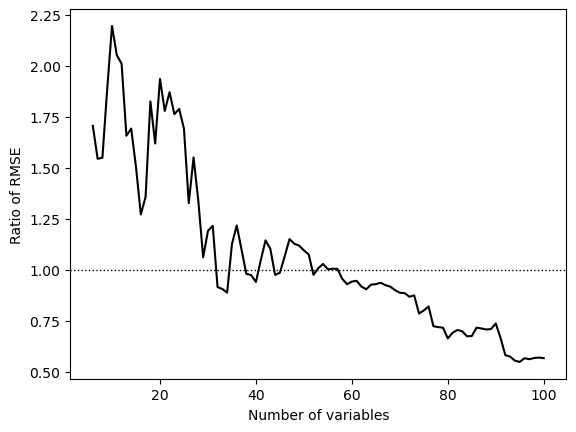

Total specifications selected: 52. 
 Best-RMSE selected variables 95 out of 300


,type,series,name,ticket,freq,unstructured,nominal,block_g,block_s,block_r,block_l,months_lag,agg_method
10,X,"imports_mineral_fuels,_lubricants_and_related_...",NaN,XIMP1009,q,0,1,1,0,1,0,0,mean
11,X,imports_miscellaneous_manufactured_articles,NaN,XIMP1010,q,0,1,1,0,1,0,0,mean
15,F,fiscal_b._taxes_on_goods_&_seervices,NaN,FREV1201,m,0,1,1,0,0,0,1,sum
19,F,fiscal_d._general_stamp_taxes,NaN,FREV1401,m,0,1,1,0,0,0,1,sum
21,F,fiscal_e._grants,NaN,FREV1501,m,0,1,1,0,0,0,1,sum
...,...,...,...,...,...,...,...,...,...,...,...,...,...
212,X,Exp_main,NaN,XEXP0000,m,0,1,1,0,1,0,0,sum
213,X,Imp_can,NaN,XIMP0010,m,0,1,1,0,1,0,0,sum
215,X,Imp_eu,NaN,XIMP0030,m,0,1,1,0,1,0,1,sum
218,G,primary_balance,NaN,GPRI0000,m,0,1,1,0,0,0,1,sum


In [4]:
import warnings
warnings.filterwarnings('ignore')

# ---------------------------------------------
# LARS-PRESELECTION
# Steps: 1) Prepare df; 2) Estimate benchmark; 3) LARS Estimation; 4) Best-variables
# ---------------------------------------------
# 1. Preparation: LARS cannot handle Missing Values or Mixed-Data
factors = 5

#pre_selected = data.resample('QS').mean()

# Aggregate according to methods described in metadata
agg_map = metadata.set_index('ticket')['agg_method'].to_dict()
agg_funcs = {
    col: (agg_map[col] if agg_map[col] in ['mean', 'last', 'sum'] else 'mean')
    for col in data.columns if col in agg_map
}
pre_selected = data.resample('QS').agg(agg_funcs)

pre_selected.index = pd.to_datetime(pre_selected.index)
pre_selected = pre_selected.dropna(how='all', axis=1)
pre_selected = pre_selected.loc[:, pre_selected.isnull().mean() <= 0.75] # Eliminate variables with more than 75% missing
pre_selected = pre_selected.fillna(pre_selected.mean(numeric_only=True)) # Fill with Mean

# data cannot include periods beyond the GDP we observe
last_gdp = data[target_variable].dropna()
last_gdp = last_gdp.index.max()
pre_selected = pre_selected[pre_selected.index <= last_gdp]
del last_gdp
# ---------------------------------------------
# 2. Benchmark RMSE
# ---------------------------------------------
X = pd.DataFrame(scaler.fit_transform(pre_selected.drop(target_variable, axis=1)))
X = X.dropna(axis=1)
pca = PCA(n_components=factors)

X = pca.fit_transform(X)
X = pd.DataFrame(X)
X.rename(columns=lambda x: f'PC_{x}', inplace=True)
X.index = pre_selected.index

X = pd.concat( [ pre_selected[[target_variable]] , X ] ,axis=1)

y_train = X[X.index<pd.to_datetime(test_start_date)][[target_variable]]
X_train = X[X.index<pd.to_datetime(test_start_date)].drop([target_variable], axis=1)

y_test = X[X.index>=pd.to_datetime(test_start_date)][[target_variable]]
X_test = X[X.index>=pd.to_datetime(test_start_date)].drop([target_variable], axis=1)

benchmark_model = LinearRegression()
benchmark_model.fit(X_train, y_train)
y_pred = benchmark_model.predict(X_test)
try :
    benchmark = np.mean( (y_test - y_pred)**2 )[0]
except :
    benchmark = np.mean( (y_test - y_pred)**2 )
print(f"OLS benchmark RMSE: {benchmark}")

# ---------------------------------------------
# 3. LARS Estimation
# ---------------------------------------------
pre_test = pre_selected[pre_selected.index>=test_start_date]
pre_selected = pre_selected[pre_selected.index<test_start_date]

# Estimate LARS over a range of variables included in the estimation
# Returns RMSE and variable choice
d = []
for size in range(5,100) :
    selection, rmse = lars_variable_ranking(pre_selected, target=target_variable, max_vars=size+1, test = pre_test, factors = factors)
    b = {
        "size" : size+1 ,
        "selected_vars" : selection ,
        "rmse" : rmse
    }
    d.append(b)
d = pd.DataFrame(d)
d.set_index('size', inplace=True)

# RMSE is a ratio with respect to benchmark
d['ratio'] = d['rmse']/benchmark

# Minimum RMSE:
# d.loc[d['rmse'].idxmin()]

# ---------------------------------------------
# 4. Best models: define top models and add them to specification list
# ---------------------------------------------

# ---------------------------------------------
# Plot LARS results
# ---------------------------------------------
threshold = d['ratio'].mean()
# Best threshold is 1: where models outperform non-selected OLS
threshold = 1
# define optimal factors using pre-selected
# optimal_r = estimate_factors(pre_selected.drop(target_variable, axis=1), r_max= 20 , criterion='IC1')
d['ratio'].plot(color='black')
plt.axhline(y=threshold, color='black', linestyle=':', linewidth=1)
plt.ylabel("Ratio of RMSE")
plt.xlabel("Number of variables")
plt.legend().set_visible(False)
plt.savefig(f"{PATH_OUTPUT}/ratio_plot.png", dpi=300, bbox_inches='tight')
plt.show()
# ---------------------------------------------

# ---------------------------------------------
# Keep specifications where rmse is below the threshold
# These are the top models
# ---------------------------------------------

spec_list = d[d['ratio']<threshold]
spec_list['selected_vars'] = spec_list['selected_vars'].apply(lambda x: ' '.join(x))
# ---------------------------------------------

# Variables included in best-RMSE LARS:
top_vars = spec_list.loc[spec_list['rmse'].idxmin(), 'selected_vars'].split(" ")
# Variable selection in best-RMSE LARS:
print(f"Total specifications selected: {len(spec_list)}. \n Best-RMSE selected variables {len(top_vars)} out of {len(data.columns)-1}")

# Now define main df using only variables selected
# data = data[[target_variable] + top_vars]

# ---------------------------------------------
# What variables are included in the top selection?
# ---------------------------------------------
del pre_selected
metadata[metadata['ticket'].isin(top_vars)]

Select only one specification

In [5]:
spec_list = spec_list[spec_list.rmse==spec_list.rmse.min()]
spec_list

,selected_vars,rmse,ratio
size,,,
95,FREV1801 RARR2008 RARR3026 GPRI0000 RARR2000 R...,1.165128,0.547095


# Spec

In [ ]:
import warnings
warnings.filterwarnings('ignore')

'''
spec_list expansion
'''

spec_list["spec"] = "lars" + spec_list.index.astype(str)
spec_list.loc[spec_list["rmse"].idxmin(), "spec"] = "bench" + str(spec_list["rmse"].idxmin())

spec_list["gdp_lags"] = 0
spec_list["PCA"] = 0
spec_list["data_flat"] = 3

temp = spec_list.copy()

# ------------------------------------------------
# Add combinations with different flat levels
temp2 = temp.copy()

spec_list["data_flat"] = 4
temp2["spec"] = "flats" + temp2.index.astype(str)

spec_list = pd.concat( [ spec_list, temp2 ] , axis=0 )


# new baseline
temp = spec_list.copy()
# ------------------------------------------------
# Add combinations: using PCA=5 and 3
temp2 = temp.copy()

temp2["PCA"] = 5
temp2["spec"] = temp2["spec"] +  "p5"

spec_list = pd.concat( [ spec_list, temp2 ] , axis=0 )

temp2 = temp.copy()
temp2["PCA"] = 3
temp2["spec"] = temp2["spec"] + "p3"

spec_list = pd.concat( [ spec_list, temp2 ] , axis=0 )

# ------------------------------------------------
# Add iteration with lags
temp2 = spec_list[spec_list['spec'].str.contains("p5") & spec_list['spec'].str.contains("flats")]
temp2["gdp_lags"] = 2
temp2["spec"] = temp2["spec"] +  "l2"
spec_list = pd.concat( [ spec_list, temp2 ] , axis=0 )

del temp
del temp2
#spec_list.to_csv(f'{PATH_DATA}/spec_lars.csv')
print(f"Total iterations: {len(spec_list)}")

spec_target = spec_list.copy()

Total iterations: 7


,selected_vars,rmse,ratio,spec,gdp_lags,PCA,data_flat
size,,,,,,,
95,FREV1801 RARR2008 RARR3026 GPRI0000 RARR2000 R...,1.165128,0.547095,bench95,0,0,4
95,FREV1801 RARR2008 RARR3026 GPRI0000 RARR2000 R...,1.165128,0.547095,flats95,0,0,3
95,FREV1801 RARR2008 RARR3026 GPRI0000 RARR2000 R...,1.165128,0.547095,bench95p5,0,5,4
95,FREV1801 RARR2008 RARR3026 GPRI0000 RARR2000 R...,1.165128,0.547095,flats95p5,0,5,3
95,FREV1801 RARR2008 RARR3026 GPRI0000 RARR2000 R...,1.165128,0.547095,bench95p3,0,3,4
95,FREV1801 RARR2008 RARR3026 GPRI0000 RARR2000 R...,1.165128,0.547095,flats95p3,0,3,3
95,FREV1801 RARR2008 RARR3026 GPRI0000 RARR2000 R...,1.165128,0.547095,flats95p5l2,2,5,3


In [7]:
d = {
    'size' : 9 ,
    'selected_vars' : 'UGTR1001 UBMB0000 UNTL3105 RARR2000 RARR1000 MLOA0000 EBRE0000 XSP50000 XIMP0000 XEXP0040 XIMP0040' ,
    'spec' : 'human1' ,
    'gdp_lags' : 2,
    'PCA' : 5,
    'data_flat' : 2
}
spec_target = pd.concat( [ spec_list[1:2], pd.DataFrame( [ d ] ).set_index('size') ] , axis=0)
spec_target


,selected_vars,rmse,ratio,spec,gdp_lags,PCA,data_flat
size,,,,,,,
95,FREV1801 RARR2008 RARR3026 GPRI0000 RARR2000 R...,1.165128,0.547095,flats95,0,0,3
9,UGTR1001 UBMB0000 UNTL3105 RARR2000 RARR1000 M...,NaN,NaN,human1,2,5,2


## Nowcasting in one specification

In [10]:
import warnings
warnings.filterwarnings('ignore')

import timeit
start = timeit.default_timer()

try :
    stop
    results_table = pd.read_excel(f"{PATH_OUTPUT}/{forecast_file}", index_col='date')
    performance_table = pd.read_excel(f"{PATH_OUTPUT}/{performance_file}", index_col='Vintage')
    outofsample_table = pd.read_excel(f"{PATH_OUTPUT}/{outofsample_file}", index_col='date')
    print("Existing files loaded.")
except :
    print("No former files exist. Starting from spec 1.")
    performance_table = pd.DataFrame()
    result_table = pd.DataFrame()
    outofsample_table = pd.DataFrame()

print(f"Running and saving in: {performance_file}")

for index, row in tqdm(spec_target.iterrows(), total=len(spec_target), desc="Processing Specs"):
    spec = row['spec']
    #print(f"Current estimation: {spec}")
    if 'spec' in performance_table.columns and spec in performance_table.spec.unique() : continue
    
    XVars = row['selected_vars'].split(" ")
    
    # define all model parameters
    gdp_lags = row.get('gdp_lag', 0)
    param_pca = row.get('PCA', 3)

    data_flat = row.get('data_flat', 3)
    
    dt_n = row.get('dt_n', _iter_)
    rf_n = row.get('rf_n', dt_n)
    gbt_n = row.get('gbt_n', dt_n)
    
    df = data[[ col for col in data.columns if col in XVars or col == target_variable ]]
    
    # GENERATE TRAIN/TEST DATASET
    df = df.reset_index(drop=False)
    df.dropna(axis=1, thresh=23, inplace=True)
    test = df.loc[(df.date >= train_start_date) & (df.date <= test_end_date), :].reset_index(drop=True)
    # DATES AND ACTUAL VALUES
    dates = ( pd.date_range(test_start_date, test_end_date, freq="3MS").strftime("%Y-%m-%d").tolist() )
    actuals = list(test.loc[test.date.astype(str).isin(dates), target_variable].values)
    
    pred_ols = { k: [] for k in lags }
    pred_olsr = { k: [] for k in lags }
    pred_enet = { k: [] for k in lags }
    pred_lasso = { k: [] for k in lags }
    pred_dt = { k: [] for k in lags }
    pred_rf = { k: [] for k in lags }
    pred_gbt = { k: [] for k in lags }
    pred_lstm = { k: [] for k in lags }
    
    for date in dates : 

        # define train dataset
        train = test.loc[test.date <= str(pd.to_datetime(date) - pd.tseries.offsets.DateOffset(months=3))[:10],:]
        transformed_train = mean_fill_dataset(train, train)
        
        # -----------------------------------------------------------------
        # Run PCA scaling
        if param_pca != False or param_pca != 0 :
            if param_pca == True: param_pca=1
            X = pd.DataFrame(scaler.fit_transform(transformed_train.set_index('date').drop(target_variable, axis=1)))
            X.columns = transformed_train.set_index('date').drop(target_variable, axis=1).columns
            X = X.dropna(axis=1)
            pca = PCA(n_components=param_pca)
            
            X = pca.fit_transform(X)
            X = pd.DataFrame(X)
            X.rename(columns=lambda x: f'PC_{x}', inplace=True)
            transformed_train = pd.concat( [ transformed_train[['date', target_variable]] , X ] ,axis=1)
        
        ttrain = flatten_data(transformed_train, target_variable, data_flat )
        # only keep quarterly observations and drop early observations with not enough history for lagged variables
        ttrain = ttrain.loc[ttrain.date.dt.month.astype(int).isin([3,6,9,12]),:].fillna(ttrain.mean()).dropna(axis=1).reset_index(drop=True)
        ttrain = lagged_target(ttrain, gdp_lags)

        xt = ttrain.drop(["date", target_variable], axis=1)
        yt = ttrain[target_variable]

        # -----------------------------------------------------------------
        # Apply model in train
        #start_time = time.time()
        if run['ols'] == 1 :
            ols_fit, ols_vars = fit_ols( 
                yt , 
                xt ,
            )
        if run['olsr']==1 :
            olsr_fit, olsr_vars = fit_olsr( 
                yt , 
                xt , 
            )
        if run['enet']==1 :
            enet_fit, enet_vars = fit_enet( 
                yt , 
                xt ,
            )
        if run['lasso']==1 :
            lasso_fit, lasso_vars = fit_lasso( 
                yt , 
                xt ,
            )
        if run['dt']==1 :
            dt_fit, dt_vars = fit_dt( 
                yt , 
                xt ,
                ModelN = dt_n,
            )
        if run['rf']==1 :
            rf_fit, rf_vars = fit_rf( 
                yt , 
                xt ,
                ModelN = rf_n,
            )
        if run['gbt']==1 :
            gbt_fit, gbt_vars = fit_gbt( 
                yt , 
                xt ,
                ModelN = gbt_n,
            )
        if run['lstm']==1 :
            lstm_fit, lstm_vars = fit_lstm( 
                transformed_train , 
                gdp_lags = gdp_lags,
            )
        #end_time = time.time()
        #print(f"Model Fit time: {end_time - start_time}")

        # -----------------------------------------------------------------
        # Publication Lags in Test data
        #start_time = time.time() 
        for lag in lags:
            # the data available for this date at this artificial vintage
            tmp_data = gen_lagged_data(metadata, test, date, lag)
            # get data in format necessary for model
            tmp_data = mean_fill_dataset(train, tmp_data)
            
            if param_pca != False or param_pca != 0 :                    
                X = pd.DataFrame(scaler.fit_transform(tmp_data.set_index('date').drop(target_variable, axis=1)))
                X.columns = tmp_data.set_index('date').drop(target_variable, axis=1).columns
                X = X.dropna(axis=1)
                pca = PCA(n_components=param_pca)
                
                X = pca.fit_transform(X)
                X = pd.DataFrame(X)
                X.rename(columns=lambda x: f'PC_{x}', inplace=True)
                
                tmp_data = pd.concat( [ tmp_data[['date', target_variable]] , X ] ,axis=1)

            test_data = flatten_data(tmp_data, target_variable, data_flat )
            test_data = lagged_target(test_data, data_flat)
            
            test_data = test_data.loc[test_data['date']== date, :].drop(["date", target_variable], axis=1)

            # -----------------------------------------------------------------
            # Predicted values
            if run['ols']==1 :
                pred_ols = predict_ols(
                    model=ols_fit,
                    X = test_data ,
                    train_vars = ols_vars,
                    date = date,
                    pred_dict = pred_ols ,
                    l = lag, 
                    )
            
            if run['olsr']==1 :
                pred_olsr = predict_olsr(
                    model=olsr_fit,
                    X = test_data ,
                    date = date,
                    train_vars = olsr_vars,
                    pred_dict = pred_olsr ,
                    l = lag, 
                    )
            if run['enet']==1 :
                pred_enet = predict_enet(
                    model=enet_fit,
                    X = test_data ,
                    date = date,
                    train_vars = enet_vars,
                    pred_dict = pred_enet ,
                    l = lag, 
                    )
            if run['lasso']==1 :
                pred_lasso = predict_lasso(
                    model=lasso_fit,
                    X = test_data ,
                    date = date,
                    train_vars = lasso_vars,
                    pred_dict = pred_lasso ,
                    l = lag, 
                    )
            if run['dt']==1 :
                pred_dt = predict_dt(
                    model=dt_fit,
                    X = test_data ,
                    date = date,
                    train_vars = dt_vars,
                    pred_dict = pred_dt ,
                    l = lag, 
                    )
            if run['rf']==1 :
                pred_rf = predict_rf(
                    model=rf_fit,
                    X = test_data ,
                    date = date,
                    train_vars = rf_vars,
                    pred_dict = pred_rf ,
                    l = lag, 
                    )
            if run['gbt']==1 :
                pred_gbt = predict_gbt(
                    model=gbt_fit,
                    X = test_data ,
                    date = date,
                    train_vars = gbt_vars,
                    pred_dict = pred_gbt ,
                    l = lag, 
                    )
            if run['lstm']==1 :
                pred_lstm = predict_lstm(
                    model=lstm_fit,
                    X = tmp_data ,
                    date = date,
                    train_vars = lstm_vars,
                    pred_dict = pred_lstm ,
                    l = lag, 
                    gdp_lags=gdp_lags,
                    )
        #end_time = time.time()
        #print(f"Step Model Predict (all vintages) time: {end_time - start_time}")
    
    # -----------------------------------------------------------------
    # -----------------------------------------------------------------
    # Prepare Tables
    if run['ols']==1 :
        performance_table = pd.concat( [ performance_table , perform_tab(pred_ols, "OLS", spec , actuals) ], axis=0)
        result_table = pd.concat( [ result_table , forecast_table(pred_ols, "OLS", spec , actuals, dates) ], axis=0)
    
    if run['olsr']==1 :
        performance_table = pd.concat( [ performance_table , perform_tab(pred_olsr, "OLSR", spec , actuals) ], axis=0)
        result_table = pd.concat( [ result_table , forecast_table(pred_olsr, "OLSR", spec , actuals, dates) ], axis=0)
    
    if run['enet']==1 :
        performance_table = pd.concat( [ performance_table , perform_tab(pred_enet, "ENET", spec , actuals) ], axis=0)
        result_table = pd.concat( [ result_table , forecast_table(pred_enet, "ENET", spec , actuals, dates) ], axis=0)
    
    if run['lasso']==1 :
        performance_table = pd.concat( [ performance_table , perform_tab(pred_lasso, "LASSO", spec , actuals) ], axis=0)
        result_table = pd.concat( [ result_table , forecast_table(pred_lasso, "LASSO", spec , actuals, dates) ], axis=0)
    
    if run['dt']==1 :
        performance_table = pd.concat( [ performance_table , perform_tab(pred_dt, "DT", spec , actuals) ], axis=0)
        result_table = pd.concat( [ result_table , forecast_table(pred_dt, "DT", spec , actuals, dates) ], axis=0)
    
    if run['rf']==1 :
        performance_table = pd.concat( [ performance_table , perform_tab(pred_rf, "RF", spec , actuals) ], axis=0)
        result_table = pd.concat( [ result_table , forecast_table(pred_rf, "RF", spec , actuals, dates) ], axis=0)
    
    if run['gbt']==1 :
        performance_table = pd.concat( [ performance_table , perform_tab(pred_gbt, "GBT", spec , actuals) ], axis=0)
        result_table = pd.concat( [ result_table , forecast_table(pred_gbt, "GBT", spec , actuals, dates) ], axis=0)
    
    if run['lstm']==1 :
        performance_table = pd.concat( [ performance_table , perform_tab(pred_lstm, "LSTM", spec , actuals) ], axis=0)
        result_table = pd.concat( [ result_table , forecast_table(pred_lstm, "LSTM", spec , actuals, dates) ], axis=0)
    
    
    # -----------------------------------------------------------------
    # -----------------------------------------------------------------
    # OUT OF SAMPLE ESTIMATION
    #start_time = time.time()
    if desired_date != None :
        while desired_date > df['date'].max(): df.loc[len(df), "date"] = df['date'].max() + pd.DateOffset(months=1)
        transformed_new_data = mean_fill_dataset(df, df) # we can use the latest data for mean filling, since this isn't for model assessment but inference
        
        if param_pca != False or param_pca != 0 :                    
            X = pd.DataFrame(scaler.fit_transform(transformed_new_data.set_index('date').drop(target_variable, axis=1)))
            X.columns = transformed_new_data.set_index('date').drop(target_variable, axis=1).columns
            X = X.dropna(axis=1)
            pca = PCA(n_components=param_pca)
            
            X = pca.fit_transform(X)
            X = pd.DataFrame(X)
            X.rename(columns=lambda x: f'PC_{x}', inplace=True)
            
            transformed_new_data = pd.concat( [ transformed_new_data[['date', target_variable]] , X ] ,axis=1)
        
        transformed_data = flatten_data(transformed_new_data, target_variable, data_flat)
        transformed_data = lagged_target(transformed_data, gdp_lags)
        transformed_data = transformed_data[ transformed_data['date'] > date ]
        transformed_data = transformed_data[transformed_data['date'] <= desired_date ]
        transformed_data = transformed_data.loc[transformed_data.date.dt.month.astype(int).isin([3,6,9,12]),:].fillna(transformed_train.mean()).dropna(axis=1)
        new_dates = transformed_data['date']
        transformed_data = transformed_data.drop(["date", target_variable], axis=1).reset_index(drop=True)

        # Run Out of Sample forecast
        if run['ols']==1 :
            outofsample_table = oos_ols(
                ols_fit ,
                transformed_data,
                train_vars = ols_vars ,
                table = outofsample_table,
                spec = spec ,
                )
        if run['olsr']==1 :
            outofsample_table = oos_olsr(
                olsr_fit ,
                transformed_data,
                train_vars = olsr_vars ,
                table = outofsample_table,
                spec = spec ,
                )
        if run['enet']==1 :
            outofsample_table = oos_enet(
                enet_fit ,
                transformed_data,
                train_vars = enet_vars ,
                table = outofsample_table,
                spec = spec ,
                )
        if run['lasso']==1 :
            outofsample_table = oos_lasso(
                lasso_fit ,
                transformed_data,
                train_vars = lasso_vars ,
                table = outofsample_table,
                spec = spec ,
                )
        
        if run['dt']==1 :
            outofsample_table = oos_dt(
                dt_fit ,
                transformed_data,
                train_vars = dt_vars ,
                table = outofsample_table,
                spec = spec ,
                )
        
        if run['rf']==1 :
            outofsample_table = oos_rf(
                rf_fit ,
                transformed_data,
                train_vars = rf_vars ,
                table = outofsample_table,
                spec = spec ,
                )
        if run['gbt']==1 :
            outofsample_table = oos_gbt(
                gbt_fit ,
                transformed_data,
                train_vars = gbt_vars ,
                table = outofsample_table,
                spec = spec ,
                )

        if run['lstm']==1 :
            outofsample_table = oos_lstm(
                lstm_fit ,
                transformed_new_data,
                train_vars = lstm_vars ,
                table = outofsample_table,
                spec = spec ,
                )
        
    #end_time = time.time()
    #print(f"Step Out of sample time: {end_time - start_time}")
    
    
    performance_table.to_excel(f"{PATH_OUTPUT}/{performance_file}")
    result_table.index = pd.to_datetime(result_table.index).strftime('%Y-%m-%d')
    result_table.to_excel(f"{PATH_OUTPUT}/{forecast_file}", index_label='date')
    outofsample_table.index = pd.to_datetime(outofsample_table.index).strftime('%Y-%m-%d')
    outofsample_table.to_excel(f"{PATH_OUTPUT}/{outofsample_file}", index_label='date')

run_time = timeit.default_timer() - start
print(f"Total runtime: {run_time}")
print(f"Saved in {performance_file}")

No former files exist. Starting from spec 1.
Running and saving in: perf_20260122.xlsx


Processing Specs: 100%|██████████| 2/2 [00:05<00:00,  2.62s/it]

Total runtime: 5.237794799999392
Saved in perf_20260122.xlsx


In [11]:
performance_table

,RMSE,estimator,spec
Vintage,,,
-2,1.744156,OLS,flats95
-1,5.140691,OLS,flats95
0,4.800710,OLS,flats95
1,4.831460,OLS,flats95
2,4.833850,OLS,flats95
-2,3.968117,OLS,human1
-1,6.192490,OLS,human1
0,4.512965,OLS,human1
1,3.765043,OLS,human1


In [12]:
print(performance_table['RMSE'].describe())

count    10.000000
mean      4.355452
std       1.170749
min       1.744156
25%       3.815811
50%       4.656838
75%       4.833253
max       6.192490
Name: RMSE, dtype: float64
